In [1]:
%cd ../..
%env NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="

/home/jj/Research/ConceptualSensitivityRegularization
env: NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from csr.module.utils.notebookutils import NeptuneViewer
pd.options.display.float_format = '{:,.4f}'.format

/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# 1. Get DataFrame from Neptune project

In [3]:
project_name = '240411WaterBirds'
df = NeptuneViewer.get_neptune_dataframe('smoothAttributionPrior', project_name)
print('-'*20)
print(len(df))

cktp_list = df.query('module_name == "CGR"')['g_ckpt_path'].unique()
for key, module_name in zip(['catdog_concepts_convnext_t_signal', 'catdog_concepts_convnext_t_svm', 'TEM-619'], ['RRC-SVM', 'RRC-Signal', 'CGR']):
    try:
        ckpt = [i for i in cktp_list if key in i][0]
    except:
        continue
    idx = df.query('g_ckpt_path == @ckpt').index
    df.loc[idx, 'module_name'] = module_name

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/smoothAttributionPrior/240411WaterBirds/


Fetching table...: 0 [00:00, ?/s]

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/smoothAttributionPrior/240411WaterBirds/metadata
--------------------
576


In [4]:
df['module_name'].value_counts()


module_name
CGR           240
GDRO          192
RRC-Signal     48
RRC-SVM        48
ERM            48
Name: count, dtype: int64

In [5]:
def mean_std(x):
    return f'{100*x.mean():.3f}+{100*x.std():.3f}'

def get_best_index(df, var_list, metric):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()
    return idx

def get_mean_with_given_index(df, var_list, metric, idx):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    return df_mean.reset_index().loc[idx].set_index('minor_ratio')[metric]

def get_std_with_given_index(df, var_list, metric, idx):
    df_std = df.groupby(var_list)[metric].std().sort_index()
    return df_std.reset_index().loc[idx].set_index('minor_ratio')[metric]

def sort_and_query(df, sort_by, query):
    df_temp = df.sort_values(by=sort_by)
    df_temp = df_temp.query(query)
    return df_temp

def get_wga(df, module_name):
    df_query = df.query('model == "convnext_t" and module_name == @module_name')

    ban_list = ['lr_history', 'data_seed', 'model_path', 'lr_history1']
    var_list = (df_query.nunique() >= 2) & (df_query.nunique() <= 10)
    var_list = [i for i in df.columns[var_list] if 'acc' not in i and i not in ban_list]

    expected_length = 1
    print(var_list)
    for i in var_list:
        print(i, df_query[i].nunique(), end=', ')
        expected_length *= df_query[i].nunique()
    print()
    print(f'Expected {expected_length}, got {len(df_query)}')

    idx = get_best_index(df_query, var_list, 'valid_valid_best_worst_acc')

    best_mean = get_mean_with_given_index(df_query, var_list, 'test_worst_acc', idx)
    best_std = get_std_with_given_index(df_query, var_list, 'test_worst_acc', idx)
    test_acc_mean = get_mean_with_given_index(df_query, var_list, 'test_acc', idx)
    test_acc_std = get_std_with_given_index(df_query, var_list, 'test_acc', idx)

    return idx, best_mean, best_std, test_acc_mean, test_acc_std

['batch_size_train', 'learning_rate', 'minor_ratio']
batch_size_train 2, learning_rate 4, minor_ratio 2, 
Expected 16, got 48
['g_ckpt_path', 'lamb_cs', 'learning_rate', 'minor_ratio']
g_ckpt_path 5, lamb_cs 8, learning_rate 2, minor_ratio 2, 
Expected 160, got 240
['lamb_cs', 'learning_rate', 'minor_ratio']
lamb_cs 8, learning_rate 2, minor_ratio 2, 
Expected 32, got 48
['lamb_cs', 'learning_rate', 'minor_ratio']
lamb_cs 8, learning_rate 2, minor_ratio 2, 
Expected 32, got 48
['eta', 'learning_rate', 'minor_ratio']
eta 8, learning_rate 4, minor_ratio 2, 
Expected 64, got 192


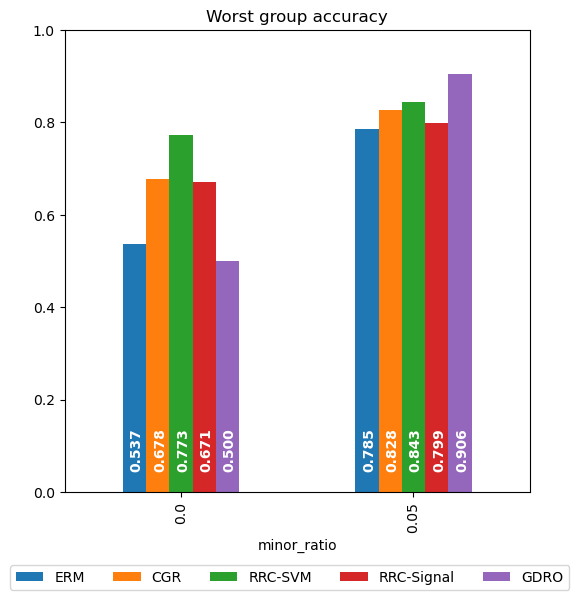

In [6]:
module_list = ['ERM', 'CGR', 'RRC-SVM', 'RRC-Signal', 'GDRO']

# get best_mean std and plot
best_idx_list = []
best_mean_list = []
best_std_list = []
test_mean_list = []
test_std_list = [] 
for module_name in module_list:
    best_idx, best_mean, best_std, test_acc_mean, test_acc_std = get_wga(df, module_name)
    best_idx_list.append(best_idx)
    best_mean_list.append(best_mean)
    best_std_list.append(best_std)
    test_mean_list.append(test_acc_mean)
    test_std_list.append(test_acc_std)

fig, ax = plt.subplots(1,1, figsize=(6,6))

best_model_mean = pd.concat(best_mean_list, axis=1)
best_model_mean.columns = module_list

# plot best model mean
bars = best_model_mean.plot(kind='bar', yerr=pd.concat(best_std_list, axis=1), ax=ax, capsize=5, legend=False, ylim=(0, 1))
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=5)
ax.set_title('Worst group accuracy')

for i, vs in enumerate(best_model_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.22 + j * 0.1 , 0.05, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)
plt.savefig('notebooks/results_viewer/figure/waterbirds_wga.png', bbox_inches='tight')
plt.show()

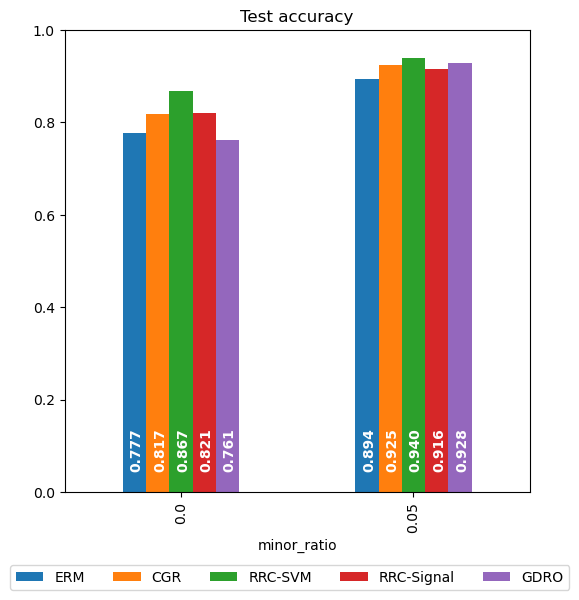

In [7]:
fig, ax = plt.subplots(1,1, figsize=(6,6))

test_mean = pd.concat(test_mean_list, axis=1)
test_mean.columns = module_list

# plot best model mean
bars = test_mean.plot(kind='bar', yerr=pd.concat(test_std_list, axis=1), ax=ax, capsize=5, legend=False, ylim=(0, 1))
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=5)
ax.set_title('Test accuracy')

for i, vs in enumerate(test_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.22 + j * 0.1 , 0.05, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)
plt.savefig('notebooks/results_viewer/figure/waterbirds_ta.png', bbox_inches='tight')
plt.show()



# CGR analysis

In [17]:
df_cgr = df.query('module_name == "CGR" and minor_ratio == 0')

vars_list = ['g_ckpt_path', 'minor_ratio', 'learning_rate', 'lamb_cs']
df_cgr.groupby(vars_list)['valid_valid_best_worst_acc'].mean().sort_values(ascending=False).head(10)

g_ckpt_path                                                                                                  minor_ratio  learning_rate  lamb_cs       
/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/.neptune/temp/TEM-648/checkpoints/last.ckpt  0.0000       0.0030         1,000.0000       0.6710
/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/data/cavs/TEM-578/checkpoints/last.ckpt      0.0000       0.0030         100,000.0000     0.6643
/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/.neptune/temp/TEM-647/checkpoints/last.ckpt  0.0000       0.0030         1,000.0000       0.6578
                                                                                                                                         1,000,000.0000   0.6545
/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/.neptune/temp/TEM-646/checkpoints/last.ckpt  0.0000       0.0030         100.0000         0.6517
/mnt/ssd/jj/Research/Maxent/ConceptualSensi

In [20]:
df_cgr = df.query('module_name == "CGR" and minor_ratio == 0.05')

vars_list = ['g_ckpt_path', 'minor_ratio', 'learning_rate', 'lamb_cs']
df_cgr.groupby(vars_list)['valid_valid_best_worst_acc'].mean().sort_values(ascending=False).head(10)

g_ckpt_path                                                                                                  minor_ratio  learning_rate  lamb_cs       
/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/.neptune/temp/TEM-647/checkpoints/last.ckpt  0.0500       0.0010         100.0000         0.8658
                                                                                                                                         1,000.0000       0.8647
                                                                                                                                         10,000.0000      0.8633
                                                                                                                                         100,000.0000     0.8633
                                                                                                                                         1,000,000.0000   0.8633
                                           

In [45]:
pth = '/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/.neptune/temp/TEM-648/checkpoints/last.ckpt'

df_cgr = df.query('module_name == "CGR" and minor_ratio == 0.05 and g_ckpt_path == @pth')

vars_list = ['g_ckpt_path', 'minor_ratio', 'learning_rate', 'lamb_cs']
tmp = df_cgr.groupby(vars_list)['valid_valid_best_worst_acc'].mean().reset_index()

Text(0, 0.5, 'valid_valid_best_worst_acc')

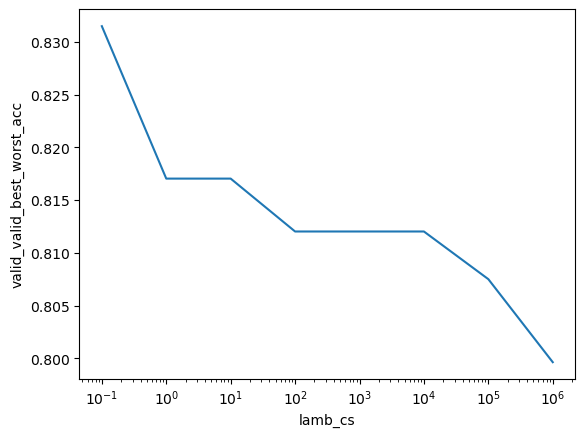

In [46]:
plt.plot(tmp['lamb_cs'], tmp['valid_valid_best_worst_acc'])
# log scale x
plt.xscale('log')
plt.xlabel('lamb_cs')
plt.ylabel('valid_valid_best_worst_acc')

In [78]:
df_cgr = df.query('module_name == "CGR"')
vars_list = ['minor_ratio', 'learning_rate', 'lamb_cs']

df_mean = df_cgr.groupby(var_list)['valid_valid_best_worst_acc'].mean().sort_index()
idx = df_mean.reset_index().groupby(['minor_ratio', 'g_ckpt_path']).idxmax()['valid_valid_best_worst_acc'].dropna()

df_mean = df_cgr.groupby(var_list)['test_worst_acc'].mean().sort_index()
best_mean = df_mean.reset_index().loc[idx].set_index(['minor_ratio', 'g_ckpt_path'])

In [79]:
best_mean

lamb_cs  \
minor_ratio g_ckpt_path                                                       
0.0000      /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi... 100,000.0000   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...     100.0000   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...   1,000.0000   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...   1,000.0000   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi... 100,000.0000   
0.0500      /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi... 100,000.0000   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...       0.1000   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...     100.0000   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...       0.1000   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...       0.1000   

                                                                learning_rate  \
minor_ratio g_ckpt_path                                                         
0.0000      /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0030   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0030   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0030   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0030   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0030   
0.0500      /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0010   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0010   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0010   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0010   
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...         0.0010   

                                                                test_worst_acc  
minor_ratio g_ckpt_path                                                         
0.0000      /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.6781  
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.6595  
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.6724  
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.6778  
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.6486  
0.0500      /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.7939  
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.8079  
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.8276  
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.8103  
            /mnt/ssd/jj/Research/Maxent/ConceptualSensitivi...          0.8058

In [80]:

df_g = NeptuneViewer.get_neptune_dataframe('smoothAttributionPrior', 'temp')



[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/smoothAttributionPrior/temp/


Fetching table...: 0 [00:00, ?/s]

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/smoothAttributionPrior/temp/metadata


In [84]:
id_list = ['TEM-645', 'TEM-646', 'TEM-647', 'TEM-648']
df_g = df_g.query('id == @id_list')

In [88]:
df_g[['learning_rate', 'id']]

,learning_rate,id
0,0.0001,TEM-648
1,0.0003,TEM-647
2,0.0010,TEM-646
3,0.0030,TEM-645


<Axes: >

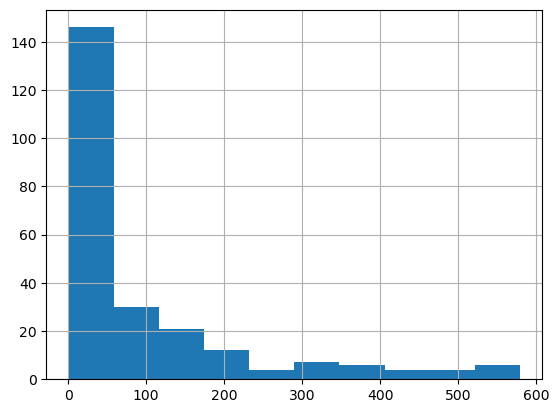

In [93]:
df_cgr['valid_valid_best_epoch'].hist()

In [95]:
pth = '/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/.neptune/temp/TEM-648/checkpoints/last.ckpt'

df_cgr = df.query('module_name == "CGR" and minor_ratio == 0.05 and g_ckpt_path == @pth')

In [99]:
df_cgr.query('lamb_cs == 100')

,id,epoch,batch_size_test,batch_size_train,cgr_stage,criterion,cs_method,data_dir,data_seed,data_type,...,valid_valid_acc,valid_valid_acc_y_0_a_0,valid_valid_acc_y_0_a_1,valid_valid_acc_y_1_a_0,valid_valid_acc_y_1_a_1,valid_valid_avg_acc,valid_valid_best_epoch,valid_valid_best_worst_acc,valid_valid_loss,valid_valid_worst_acc
149,WAT8-428,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.8807,0.9936,0.7811,0.7368,0.9774,0.8807,35.0000,0.7820,0.5827,0.7368
156,WAT8-421,600.0000,100,32,stage2,bce,dot_sq,/home/data,1235,feature,...,0.8899,0.9936,0.8090,0.7218,0.9774,0.8899,9.0000,0.8496,0.5219,0.7218
166,WAT8-411,600.0000,100,32,stage2,bce,dot_sq,/home/data,1234,feature,...,0.8766,0.9957,0.7682,0.7444,0.9699,0.8766,1.0000,0.8045,0.5384,0.7444


In [100]:
df_cgr

,id,epoch,batch_size_test,batch_size_train,cgr_stage,criterion,cs_method,data_dir,data_seed,data_type,...,valid_valid_acc,valid_valid_acc_y_0_a_0,valid_valid_acc_y_0_a_1,valid_valid_acc_y_1_a_0,valid_valid_acc_y_1_a_1,valid_valid_avg_acc,valid_valid_best_epoch,valid_valid_best_worst_acc,valid_valid_loss,valid_valid_worst_acc
144,WAT8-433,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.8224,0.9893,0.6588,0.6692,0.9624,0.8224,28.0000,0.7895,0.6332,0.6588
145,WAT8-432,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.2219,0.0000,0.0000,1.0000,1.0000,0.2219,14.0000,0.7511,1.0481,0.0000
146,WAT8-431,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.9116,0.9914,0.8648,0.7368,0.9699,0.9116,520.0000,0.8219,0.9637,0.7368
147,WAT8-430,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.2219,0.0000,0.0000,1.0000,1.0000,0.2219,80.0000,0.7747,1.0481,0.0000
148,WAT8-429,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.8249,0.9850,0.7017,0.5789,0.9398,0.8249,53.0000,0.7820,0.7030,0.5789
149,WAT8-428,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.8807,0.9936,0.7811,0.7368,0.9774,0.8807,35.0000,0.7820,0.5827,0.7368
150,WAT8-427,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.8991,0.9936,0.8326,0.7293,0.9699,0.8991,10.0000,0.8045,0.7070,0.7293
151,WAT8-426,600.0000,100,32,stage2,bce,dot_sq,/home/data,1236,feature,...,0.9074,0.9957,0.8562,0.7218,0.9624,0.9074,550.0000,0.8045,0.7715,0.7218
152,WAT8-425,600.0000,100,32,stage2,bce,dot_sq,/home/data,1235,feature,...,0.7781,1.0000,1.0000,0.0000,0.0000,0.7781,10.0000,0.8433,1.0480,0.0000
153,WAT8-424,600.0000,100,32,stage2,bce,dot_sq,/home/data,1235,feature,...,0.9033,0.9979,0.8433,0.7143,0.9699,0.9033,1.0000,0.8421,0.9805,0.7143
